In [24]:
import sys
import os
sys.path.append(os.path.abspath("../src"))


noise: tensor([[-1.2852,  0.4853, -0.1158, -0.6758, -1.3568, -0.1169, -0.1228,  0.3660,
         -0.5894,  1.7202,  1.5551, -0.0191, -0.2376,  0.0917,  0.5531, -0.3932,
          0.2132,  1.3264,  1.7370,  1.2153,  1.0422,  0.2678, -1.0281,  1.6127,
          0.9731,  2.4327, -0.6534, -0.2492, -0.8454, -0.8694, -0.8991,  0.8962,
         -0.5452, -1.0836,  0.2005, -0.3110, -1.0407, -0.5070,  0.1580, -1.2754,
          1.9939, -0.4006, -0.4357, -0.3992,  0.1563,  1.1191,  0.1008,  0.4332,
         -1.4263, -0.6029, -0.9440, -0.1071,  1.0772, -0.4088, -0.0844, -1.6158,
         -0.4849,  0.2037,  0.2230,  1.3089, -0.3045,  1.3197,  0.7527, -0.6363,
         -1.4235, -0.5039,  2.0666, -0.5550,  0.2759,  0.5595,  0.1677,  0.6944,
         -0.5894,  0.1931,  0.0969, -0.4046,  0.7626,  0.9417, -0.0144,  0.0639,
         -0.0454,  0.4153, -1.1601, -0.2084,  1.0972,  0.9505,  0.6090, -0.7378,
         -1.5884, -0.9122, -0.5781,  0.0080,  0.6598, -0.1002, -0.2767, -0.2946,
         -0.2473, -0.

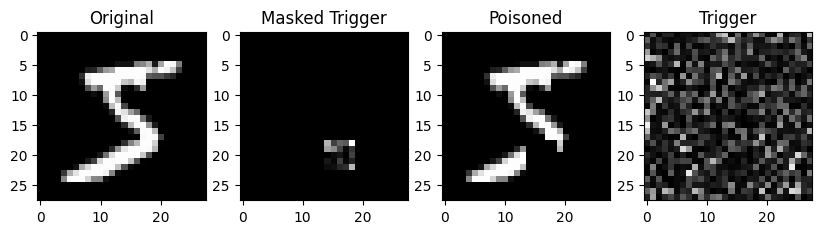

In [29]:
import torch
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from model.cban_generator import CBaNGenerator
from utils.trigger_utils import apply_trigger_masked, generate_random_mask

# Load model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = CBaNGenerator().to(device)
generator.load_state_dict(torch.load("../models/cban_generator.pth", map_location=device))
generator.eval()

# Load sample
dataset = datasets.MNIST(root="../data", train=True, transform=transforms.ToTensor(), download=True)
image, label = dataset[0]

# Generate trigger
noise = torch.randn(1, 100).to(device)
target_label = torch.nn.functional.one_hot(torch.tensor([label]), num_classes=10).float().to(device)
print("noise:", noise)
print("target label:", target_label)
trigger = generator(noise, target_label)

# Apply trigger
image_tensor = image.unsqueeze(0).to(device)
mask = generate_random_mask(image_shape=(28, 28), patch_size=5).to(device)
masked_trigger = trigger * mask
poisoned = apply_trigger_masked(image_tensor.squeeze(), masked_trigger.squeeze(), mask)

# Visualize
fig, axes = plt.subplots(1, 4, figsize=(10, 4))
axes[0].imshow(image.squeeze(), cmap='gray'); axes[0].set_title("Original")
axes[1].imshow(masked_trigger.squeeze().detach().cpu(), cmap='gray'); axes[1].set_title("Masked Trigger")
axes[2].imshow(poisoned.squeeze().detach().cpu(), cmap='gray'); axes[2].set_title("Poisoned")
axes[3].imshow(trigger.squeeze().detach().cpu(), cmap='gray'); axes[3].set_title("Trigger")
plt.show()

In [5]:
from torch.utils.data import DataLoader
from data.poisoned_mnist import PoisonedMNISTDataset


poisoned_dataset = PoisonedMNISTDataset(
    root="../data",
    generator_ckpt="../models/cban_generator.pth",
    poison_rate=0.3,
    target_label=0
)

poisoned_loader = DataLoader(poisoned_dataset, batch_size=64, shuffle=True)
